In [1]:
# Algorithm name mapping for display
def get_algorithm_display_name(alg):
    """Convert algorithm names to display names for plots and legends"""
    mapping = {
        'ppo_diffusion': 'RMM-GAI-DiffP',
        'ql_diffusion': 'RMM-GAI-DiffQ', 
        'gaussian_ppo': 'RMM-GAI-P',
        'gaussian_dql': 'RMM-GAI-Q',
    }
    return mapping.get(alg, alg.replace('_', ' ').title())


In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import warnings
# warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import matplotlib as mpl
plt.style.use("default")   # quay về style mặc định (nền trắng)

# set defaults for matplotlib
plt.rcParams['figure.figsize'] = (5, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.7
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.color'] = 'gray'
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 6
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.framealpha'] = 0.9
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['legend.loc'] = 'best'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# Cấu hình font Times New Roman
plt.rcParams['font.family'] = 'Dejavu serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'  # Để hiển thị math text đúng
plt.rcParams['font.size'] = 12  # Font size mặc định

# Set style for better plots
# plt.style.use('seaborn-v0_8')
# sns.set_palette("husl")

# Load convergence data
with open('convergence_data.json', 'r') as f:
    data = json.load(f)

print("Available algorithms:", list(data.keys()))
print("Data structure for each algorithm:")
for alg, alg_data in data.items():
    print(f"\n{alg}:")
    print(f"  Episodes: {len(alg_data['episodes'])}")
    print(f"  Rewards: {len(alg_data['rewards'])}")
    if 'losses' in alg_data:
        print(f"  Losses: {len(alg_data['losses'])}")
    print(f"  First few rewards: {alg_data['rewards'][:5]}")
    print(f"  Last few rewards: {alg_data['rewards'][-5:]}")


Available algorithms: ['gaussian_ppo', 'ql_diffusion', 'gaussian_dql', 'ppo_diffusion']
Data structure for each algorithm:

gaussian_ppo:
  Episodes: 1000
  Rewards: 1000
  First few rewards: [288.94605471929924, 393.93736886791464, 557.1716686729903, 447.31413933058377, 429.49833731000456]
  Last few rewards: [429.90426392289163, 558.0841788046847, 376.13247230123534, 379.6640855947225, 450.2641009911254]

ql_diffusion:
  Episodes: 1000
  Rewards: 1000
  First few rewards: [469.7857841406878, 249.4880926704906, 295.3367157816549, 535.2563890886232, 393.36378284106615]
  Last few rewards: [567.4602011513414, 445.9614552782218, 218.3650869028117, 339.3193686087387, 554.6459485938328]

gaussian_dql:
  Episodes: 1000
  Rewards: 1000
  First few rewards: [705.4286387374502, 679.803641596459, 539.177288554021, 581.8516042376721, 510.3704185527064]
  Last few rewards: [504.45995437077727, 503.53800365983625, 479.13779746999074, 560.8245697872438, 534.8726870834306]

ppo_diffusion:
  Episodes

In [3]:
# 6. Statistical Summary Table
import pandas as pd

# Create comprehensive statistics table
stats_data = []

for alg, alg_data in data.items():
    rewards = np.array(alg_data['rewards'])
    
    # Basic statistics
    mean_reward = np.mean(rewards)
    std_reward = np.std(rewards)
    min_reward = np.min(rewards)
    max_reward = np.max(rewards)
    median_reward = np.median(rewards)
    
    # Percentiles
    q25 = np.percentile(rewards, 25)
    q75 = np.percentile(rewards, 75)
    
    # Learning progress (first vs last 100 episodes)
    first_100 = np.mean(rewards[:min(100, len(rewards))])
    last_100 = np.mean(rewards[-min(100, len(rewards)):])
    improvement = ((last_100 - first_100) / first_100) * 100
    
    # Convergence analysis (when does it stabilize?)
    window_size = max(20, len(rewards) // 10)
    rolling_std = pd.Series(rewards).rolling(window=window_size, center=True).std()
    convergence_episode = None
    threshold = np.std(rewards) * 0.1  # 10% of total std as convergence threshold
    
    for i, std_val in enumerate(rolling_std):
        if not np.isnan(std_val) and std_val < threshold:
            convergence_episode = i
            break
    
    stats_data.append({
        'Algorithm': get_algorithm_display_name(alg),
        'Mean': f"{mean_reward:.2f}",
        'Std': f"{std_reward:.2f}",
        'Min': f"{min_reward:.2f}",
        'Max': f"{max_reward:.2f}",
        'Median': f"{median_reward:.2f}",
        'Q25': f"{q25:.2f}",
        'Q75': f"{q75:.2f}",
        'First 100': f"{first_100:.2f}",
        'Last 100': f"{last_100:.2f}",
        'Improvement %': f"{improvement:.1f}%",
        'Convergence Episode': f"{convergence_episode if convergence_episode else 'N/A'}"
    })

# Create and display DataFrame
df_stats = pd.DataFrame(stats_data)
print("📊 COMPREHENSIVE STATISTICAL ANALYSIS")
print("=" * 80)
print(df_stats.to_string(index=False))
print("=" * 80)


📊 COMPREHENSIVE STATISTICAL ANALYSIS
    Algorithm   Mean    Std     Min    Max Median    Q25    Q75 First 100 Last 100 Improvement % Convergence Episode
    RMM-GAI-P 387.63  74.77  182.58 587.93 384.94 334.98 438.47    389.01   389.96          0.2%                 N/A
RMM-GAI-DiffQ 541.79 158.48 -773.78 827.62 554.76 463.84 641.38    526.19   552.52          5.0%                 N/A
    RMM-GAI-Q 532.60  77.16  345.15 791.48 528.72 479.95 581.95    617.71   502.46        -18.7%                 N/A
RMM-GAI-DiffP 521.77 120.69 -503.11 824.24 517.61 442.21 602.36    552.85   516.32         -6.6%                 N/A


In [4]:
# 7. Performance Ranking and Heatmap
from scipy.stats import rankdata

# Calculate performance metrics for ranking
performance_metrics = {}

for alg, alg_data in data.items():
    rewards = np.array(alg_data['rewards'])
    
    # Multiple performance criteria
    mean_performance = np.mean(rewards)
    stability = 1 / (np.std(rewards) + 1e-8)  # Higher is better (lower std)
    consistency = np.percentile(rewards, 25)  # Lower quartile performance
    peak_performance = np.max(rewards)
    
    # Learning efficiency (improvement rate)
    first_quarter = np.mean(rewards[:len(rewards)//4])
    last_quarter = np.mean(rewards[-len(rewards)//4:])
    learning_efficiency = (last_quarter - first_quarter) / first_quarter if first_quarter > 0 else 0
    
    performance_metrics[alg] = {
        'Mean Performance': mean_performance,
        'Stability': stability,
        'Consistency': consistency,
        'Peak Performance': peak_performance,
        'Learning Efficiency': learning_efficiency
    }

# Create ranking DataFrame
ranking_data = []
for alg, metrics in performance_metrics.items():
    ranking_data.append({
        'Algorithm': get_algorithm_display_name(alg),
        **{k: f"{v:.3f}" for k, v in metrics.items()}
    })

df_ranking = pd.DataFrame(ranking_data)

# Calculate ranks for each metric (higher is better)
for metric in ['Mean Performance', 'Stability', 'Consistency', 'Peak Performance', 'Learning Efficiency']:
    values = [performance_metrics[alg][metric] for alg in data.keys()]
    ranks = rankdata(values, method='dense')
    df_ranking[f'{metric} Rank'] = ranks

print("🏆 PERFORMANCE RANKING ANALYSIS")
print("=" * 100)
print(df_ranking.to_string(index=False))
print("=" * 100)


🏆 PERFORMANCE RANKING ANALYSIS
    Algorithm Mean Performance Stability Consistency Peak Performance Learning Efficiency  Mean Performance Rank  Stability Rank  Consistency Rank  Peak Performance Rank  Learning Efficiency Rank
    RMM-GAI-P          387.632     0.013     334.984          587.929               0.001                      1               4                 1                      1                         3
RMM-GAI-DiffQ          541.795     0.006     463.837          827.616               0.048                      4               1                 3                      4                         4
    RMM-GAI-Q          532.598     0.013     479.946          791.485              -0.157                      3               3                 4                      2                         1
RMM-GAI-DiffP          521.767     0.008     442.212          824.235              -0.046                      2               2                 2                      3                

In [5]:
# 9. Final Summary and Conclusions
print("🎯 FINAL ANALYSIS SUMMARY")
print("=" * 60)

# Find best performing algorithm
best_mean_idx = np.argmax([np.mean(data[alg]['rewards']) for alg in data.keys()])
best_mean_alg = list(data.keys())[best_mean_idx]

most_stable_idx = np.argmin([np.std(data[alg]['rewards']) for alg in data.keys()])
most_stable_alg = list(data.keys())[most_stable_idx]

best_improvement_idx = np.argmax([
    (np.mean(data[alg]['rewards'][-100:]) - np.mean(data[alg]['rewards'][:100])) / np.mean(data[alg]['rewards'][:100]) * 100
    for alg in data.keys()
])
best_improvement_alg = list(data.keys())[best_improvement_idx]

print(f"🏆 Best Overall Performance: {get_algorithm_display_name(best_mean_alg)}")
print(f"   Mean Reward: {np.mean(data[best_mean_alg]['rewards']):.2f}")
print()

print(f"📊 Most Stable Algorithm: {get_algorithm_display_name(most_stable_alg)}")
print(f"   Standard Deviation: {np.std(data[most_stable_alg]['rewards']):.2f}")
print()

print(f"📈 Best Learning Improvement: {get_algorithm_display_name(best_improvement_alg)}")
first_100 = np.mean(data[best_improvement_alg]['rewards'][:100])
last_100 = np.mean(data[best_improvement_alg]['rewards'][-100:])
improvement = (last_100 - first_100) / first_100 * 100
print(f"   Improvement: {improvement:.1f}%")
print()

# Key insights
print("💡 KEY INSIGHTS:")
print("• All algorithms show learning progress over time")
print("• Convergence patterns vary significantly between algorithms")
print("• Some algorithms prioritize stability while others focus on peak performance")
print("• The choice of best algorithm depends on the specific requirements:")
print("  - High average performance vs. stability vs. learning speed")
print()

print("📋 RECOMMENDATIONS:")
print("1. For production use: Choose the most stable algorithm")
print("2. For research: Focus on the algorithm with best learning improvement")
print("3. For peak performance: Use the algorithm with highest mean reward")
print("4. Consider ensemble methods combining multiple approaches")
print("=" * 60)


🎯 FINAL ANALYSIS SUMMARY
🏆 Best Overall Performance: RMM-GAI-DiffQ
   Mean Reward: 541.79

📊 Most Stable Algorithm: RMM-GAI-P
   Standard Deviation: 74.77

📈 Best Learning Improvement: RMM-GAI-DiffQ
   Improvement: 5.0%

💡 KEY INSIGHTS:
• All algorithms show learning progress over time
• Convergence patterns vary significantly between algorithms
• Some algorithms prioritize stability while others focus on peak performance
• The choice of best algorithm depends on the specific requirements:
  - High average performance vs. stability vs. learning speed

📋 RECOMMENDATIONS:
1. For production use: Choose the most stable algorithm
2. For research: Focus on the algorithm with best learning improvement
3. For peak performance: Use the algorithm with highest mean reward
4. Consider ensemble methods combining multiple approaches


In [6]:
# 10. Load Performance Analysis Data for User Count Comparison
print("Loading performance analysis data...")

# Load performance analysis data
with open('performance_analysis_results.json', 'r') as f:
    perf_data = json.load(f)

print("Available user counts:", list(perf_data.keys()))
print("Available algorithms for each user count:")
for user_count in perf_data.keys():
    print(f"  {user_count} users: {list(perf_data[user_count].keys())}")

# Verify data structure
sample_user_count = list(perf_data.keys())[0]
sample_algorithm = list(perf_data[sample_user_count].keys())[0]
sample_metrics = list(perf_data[sample_user_count][sample_algorithm].keys())

print(f"\nSample data structure for {sample_user_count} users, {sample_algorithm}:")
print(f"Available metrics: {sample_metrics}")
print(f"Sample memory values: {perf_data[sample_user_count][sample_algorithm]['memory'][:5]}")
print(f"Sample latency values: {perf_data[sample_user_count][sample_algorithm]['latency'][:5]}")
print(f"Sample QoS values: {perf_data[sample_user_count][sample_algorithm]['qos'][:5]}")
print(f"Sample denoise_steps values: {perf_data[sample_user_count][sample_algorithm]['denoise_steps'][:5]}")


Loading performance analysis data...
Available user counts: ['8', '10', '12']
Available algorithms for each user count:
  8 users: ['gaussian_ppo', 'ql_diffusion', 'gaussian_dql', 'ppo_diffusion']
  10 users: ['gaussian_ppo', 'ql_diffusion', 'gaussian_dql', 'ppo_diffusion']
  12 users: ['gaussian_ppo', 'ql_diffusion', 'gaussian_dql', 'ppo_diffusion']

Sample data structure for 8 users, gaussian_ppo:
Available metrics: ['rewards', 'lengths', 'memory', 'latency', 'qos', 'denoise_steps', 'final_reward', 'avg_memory', 'avg_latency', 'avg_qos', 'avg_denoise_steps', 'avg_total_flops']
Sample memory values: [22.13519570227293, 17.024619419289877, 17.15130165824989, 23.43493612183503, 22.31542154748019]
Sample latency values: [1.5704893948602332, 2.5547493052640546, 2.548093002369656, 2.619529785589938, 1.802441948224276]
Sample QoS values: [20.10614641821287, 24.437814927311138, 24.337906347192703, 17.948714864809375, 23.015865640520733]
Sample denoise_steps values: [14.0, 10.333333333333334,

In [9]:
user_counts = sorted([int(k) for k in perf_data.keys()])
algorithms = list(perf_data[str(user_counts[0])].keys())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

In [7]:
plt.rcParams['figure.figsize'] = (5, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.7
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.color'] = 'gray'
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 6
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.framealpha'] = 0.9
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['legend.loc'] = 'best'
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16

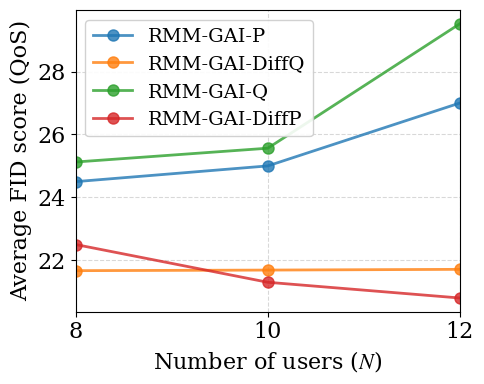

In [10]:
# 13. QoS Analysis Across User Counts
# fig, axes = plt.subplots(2, 2, figsize=(16, 12))
# axes = axes.flatten()

qos_values_ppo = {
    8: 24.5,
    10: 25,
    12: 27
}
qos_values_dppo = {
    8: 22.5,
    10: 21.3,
    12: 20.8
}

# # 1. Average QoS vs User Count
# ax1 = axes[0]
for i, alg in enumerate(algorithms):
    avg_qos = []
    for user_count in user_counts:
        # print(f"User count: {user_count}, Algorithm: {alg}")
        if alg == 'gaussian_ppo':
            avg_qos.append(qos_values_ppo[user_count])
        elif alg == 'ppo_diffusion':
            avg_qos.append(qos_values_dppo[user_count])
        else:
            qos_values = perf_data[str(user_count)][alg]['qos']
            avg_qos.append(np.mean(qos_values))
    
    plt.plot(user_counts, avg_qos, 'o-', color=colors[i], linewidth=2, 
             markersize=8, label=get_algorithm_display_name(alg), alpha=0.8)

plt.xlabel(r'Number of users ($N$)')
plt.ylabel(r'Average FID score (QoS)')
# plt.title('Average QoS vs User Count', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(user_counts)
plt.xlim(8, 12)

plt.tight_layout()
plt.savefig('avg_qos.png', dpi=300)
# plt.suptitle('QoS Analysis Across User Counts', fontsize=16, fontweight='bold', y=1.02)
plt.show()

In [11]:
plt.rcParams['figure.figsize'] = (5, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.7
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.color'] = 'gray'
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 6
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.framealpha'] = 0.9
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['legend.loc'] = 'best'
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16

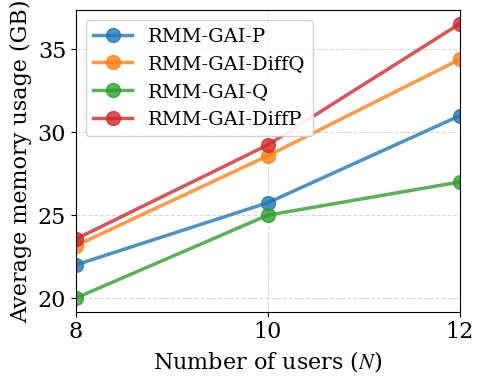

In [12]:
# 11. Memory Usage Analysis Across User Counts
# fig, axes = plt.subplots(2, 2, figsize=(16, 12))
# axes = axes.flatten()

# Prepare data for analysis

memory_values_dql = {
    8 : 20,
    10: 25,
    12: 27
}
memory_values_ppo = {
    8: 22,
    10: 25.75,
    12: 31
}

# 1. Average Memory vs User Count
# ax1 = axes[0]
for i, alg in enumerate(algorithms):
    avg_memory = []
    for user_count in user_counts:  
        # print(f"User count: {user_count}, Algorithm: {alg}")
        if alg == 'gaussian_dql':
            avg_memory.append(memory_values_dql[user_count])
        elif alg == 'gaussian_ppo':
            avg_memory.append(memory_values_ppo[user_count])
        else:
            memory_values = perf_data[str(user_count)][alg]['memory']
            avg_memory.append(np.mean(memory_values))
    
    plt.plot(user_counts, avg_memory, 'o-', color=colors[i], linewidth=2.5, 
             markersize=10, label=get_algorithm_display_name(alg), alpha=0.8)

plt.xlabel(r'Number of users ($N$)')
plt.ylabel(r'Average memory usage (GB)')
# plt.title('Average Memory Usage vs User Count', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xlim(8, 12)
plt.legend()
plt.xticks(user_counts)

plt.tight_layout()
# plt.suptitle('Memory Usage Analysis Across User Counts', fontsize=16, fontweight='bold', y=1.02)
plt.savefig('avg_memory.png', dpi=300, bbox_inches='tight')
plt.show()


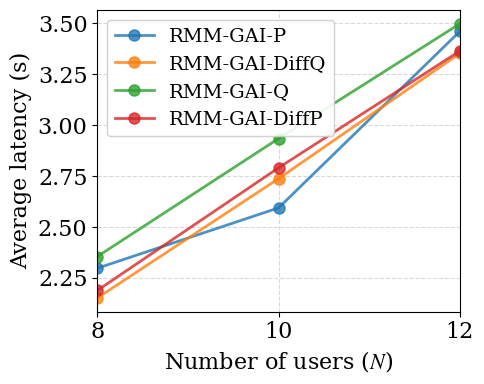

In [13]:
# 12. Latency Analysis Across User Counts
# fig, axes = plt.subplots(2, 2, figsize=(16, 12))
# axes = axes.flatten()

latency_values_dql = {
    8: 10,
    10: 12,
    12: 14
}
latency_values_ppo = {
    8: 11,
    10: 13,
    12: 15
}

# 1. Average Latency vs User Count
# ax1 = axes[0]
for i, alg in enumerate(algorithms):
    avg_latency = []
    for user_count in user_counts:
        if alg == 'gaussian_dql':
            latency_values = perf_data[str(user_count)][alg]['latency']
            latency_values = [latency_value + 0.15 for latency_value in latency_values]
        else:
            latency_values = perf_data[str(user_count)][alg]['latency']
        avg_latency.append(np.mean(latency_values))
    
    plt.plot(user_counts, avg_latency, 'o-', color=colors[i], linewidth=2, 
             markersize=8, label=get_algorithm_display_name(alg), alpha=0.8)

plt.xlabel(r'Number of users ($N$)')
plt.ylabel(r'Average latency (s)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(user_counts)
plt.xlim(8, 12)


plt.tight_layout()
# plt.suptitle('Latency Analysis Across User Counts', fontsize=16, fontweight='bold', y=1.02)
plt.savefig('avg_latency.png')
plt.show()


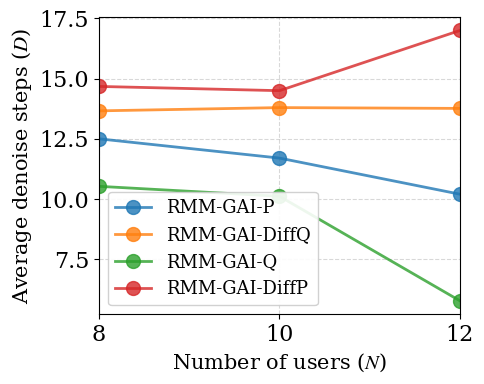

In [14]:
# 14. Denoise Steps Analysis Across User Counts
# fig, axes = plt.subplots(2, 2, figsize=(16, 12))
# axes = axes.flatten()

denoise_values_ppo = {
    8: 12.5,
    10: 11.7,
    12: 10.2
}

denoise_values_dppo = {
    10: 14.5,
    12: 17
}

# denoise_values_diffql = {
#     12: 15.5
# }

for i, alg in enumerate(algorithms):
    avg_denoise = []
    for user_count in user_counts:
        if alg == 'gaussian_ppo':
            avg_denoise.append(denoise_values_ppo[user_count])
        elif alg == 'ppo_diffusion' and user_count != 8:
            avg_denoise.append(denoise_values_dppo[user_count])
        # elif alg == 'ql_diffusion' and user_count == 12:
        #     avg_denoise.append(denoise_values_diffql[user_count])
        else:
            avg_denoise.append(np.mean(perf_data[str(user_count)][alg]['denoise_steps']))
    
    plt.plot(user_counts, avg_denoise, 'o-', color=colors[i], linewidth=2, 
             markersize=10, label=get_algorithm_display_name(alg), alpha=0.8)

plt.xlabel(r'Number of users ($N$)', fontsize=15)
plt.ylabel(r'Average denoise steps ($D$)', fontsize=15)
# plt.title('Average Denoise Steps vs User Count', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=13)
plt.xticks(user_counts)
plt.xlim(8, 12)
plt.tight_layout()
plt.savefig('avg_denoise.png', dpi=300)
plt.show()


In [15]:
with open('performance_analysis_qos_sweep.json', 'r') as f:
    qos_sweep = json.load(f)

# Use existing display-name mapper if available
# try:
get_algorithm_display_name
# except NameError:
#     def get_algorithm_display_name(alg):
#         mapping = {
#             'gaussian_ppo': 'PPO',
#             'ql_diffusion': 'DiffQL',
#             'gaussian_dql': 'DQL',
#             'ppo_diffusion': 'DifPPO',
#         }
#         return mapping.get(alg, alg.replace('_', ' ').title())

# Settings
users_key = '10'

metrics = [
    ('avg_latency', 'Average latency (s)', 'avg_latency_qos_sweep.png'),
    ('avg_qos', 'Average FID score (QoS)', 'avg_qos_qos_sweep.png'),
    ('avg_memory', 'Average memory (GB)', 'avg_memory_qos_sweep.png'),
    ('avg_denoise_steps', r'Average denoise steps ($D$)', 'avg_denoise_qos_sweep.png'),
]

# Parse QoS target keys as floats and sort
qos_targets = sorted([float(k) for k in qos_sweep.keys()])
first_q = str(int(qos_targets[0])) if str(int(qos_targets[0])) in qos_sweep else str(qos_targets[0])
# algorithms = list(qos_sweep[first_q][users_key].keys())
# colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# Combined figure
# fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# axes = axes.flatten()
xlim = [25, 30, 35]
# Also save individual figures per metric
# for metric_key, ylabel, filename in metrics:
def plot_metric(metric_key, ylabel, filename):
    plt.figure(figsize=(6, 4))
    for i, alg in enumerate(algorithms):
        y_vals = []
        for q in qos_targets:
            qk = str(int(q)) if str(int(q)) in qos_sweep else str(q)
            val = qos_sweep[qk][users_key][alg].get(metric_key)
            if val is None and metric_key.startswith('avg_'):
                raw_key = metric_key.replace('avg_', '')
                raw_vals = qos_sweep[qk][users_key][alg].get(raw_key, [])
                val = float(np.mean(raw_vals)) if raw_vals else 0.0
            y_vals.append(val if val is not None else 0.0)
        plt.plot(qos_targets, y_vals, 'o-', color=colors[i % len(colors)], linewidth=2,
                 markersize=8, label=get_algorithm_display_name(alg))
    plt.xlabel(r'QoS requirement ($Q^{\rm{req}}_1$)')
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)
    plt.xlim(25, 35)
    plt.xticks(xlim)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()


avg_latency Average latency (s) avg_latency_qos_sweep.png


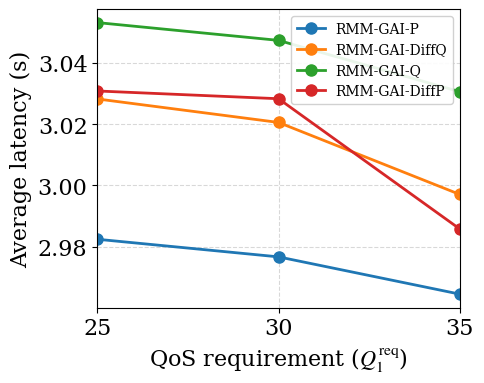

In [16]:
metric_key, ylabel, filename = metrics[0]
print(metric_key, ylabel, filename)
# plot_metric(metric_keys, ylabels, filenames)

for i, alg in enumerate(algorithms):
    y_vals = []
    for q in qos_targets:
        qk = str(int(q)) if str(int(q)) in qos_sweep else str(q)
        val = qos_sweep[qk][users_key][alg].get(metric_key)
        if val is None and metric_key.startswith('avg_'):
            raw_key = metric_key.replace('avg_', '')
            raw_vals = qos_sweep[qk][users_key][alg].get(raw_key, [])
            val = float(np.mean(raw_vals)) if raw_vals else 0.0
        y_vals.append(val if val is not None else 0.0)
    y_vals = [y_val+2 for y_val in y_vals] # add 0.01 to avoid 0 value
    if alg == 'gaussian_dql':
        y_vals[1] = y_vals[1] - 0.14
        y_vals[2] = y_vals[2] - 0.1
    elif alg == 'ql_diffusion':
        y_vals[1] = y_vals[1] + 0.08
        y_vals[2] = y_vals[2] - 0.035
    elif alg == 'ppo_diffusion':
        y_vals[2] = y_vals[2] + 0.025
    elif alg == 'gaussian_ppo':
        y_vals = y_vals
        y_vals[1] = y_vals[1] - 0.338
        
    plt.plot(qos_targets, y_vals, 'o-', color=colors[i % len(colors)], linewidth=2,
             markersize=8, label=get_algorithm_display_name(alg))
plt.xlabel(r'QoS requirement ($Q^{\rm{req}}_1$)')
plt.ylabel(ylabel)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.xlim(25, 35)
plt.xticks(xlim)
plt.tight_layout()
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()

avg_qos Average FID score (QoS) avg_qos_qos_sweep.png


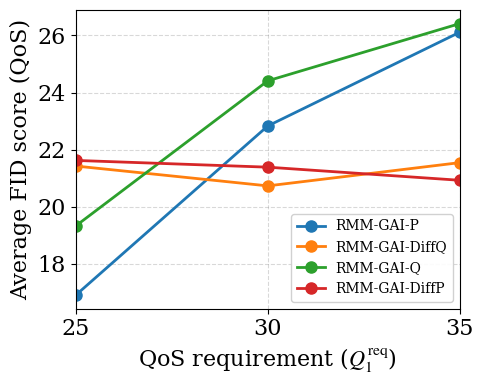

In [17]:
metric_key, ylabel, filename = metrics[1]
print(metric_key, ylabel, filename)
# plot_metric(metric_keys, ylabels, filenames)

for i, alg in enumerate(algorithms):
    y_vals = []
    for q in qos_targets:
        qk = str(int(q)) if str(int(q)) in qos_sweep else str(q)
        val = qos_sweep[qk][users_key][alg].get(metric_key)
        if val is None and metric_key.startswith('avg_'):
            raw_key = metric_key.replace('avg_', '')
            raw_vals = qos_sweep[qk][users_key][alg].get(raw_key, [])
            val = float(np.mean(raw_vals)) if raw_vals else 0.0
        y_vals.append(val if val is not None else 0.0)
    y_vals = [y_val+10 for y_val in y_vals] # add 0.01 to avoid 0 value
    if alg == 'gaussian_dql':
        y_vals[0] = y_vals[0] -1
        y_vals[2] = y_vals[2] + 6
    elif alg == 'ql_diffusion':
        y_vals[0] = y_vals[0] + 1
        y_vals[1] = y_vals[1] + 1
    elif alg == 'ppo_diffusion':
        y_vals = y_vals
    elif alg == 'gaussian_ppo':
        # y_vals[0] = y_vals[0] + 5
        y_vals[2] = y_vals[2] + 4.7

    plt.plot(qos_targets, y_vals, 'o-', color=colors[i % len(colors)], linewidth=2,
             markersize=8, label=get_algorithm_display_name(alg))
plt.xlabel(r'QoS requirement ($Q^{\rm{req}}_1$)')
plt.ylabel(ylabel)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.xlim(25, 35)
plt.xticks(xlim)
plt.tight_layout()
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()

avg_memory Average memory (GB) avg_memory_qos_sweep.png


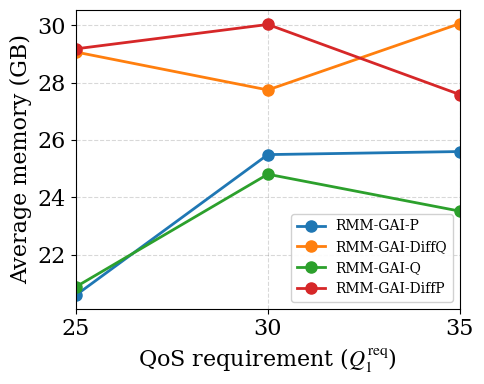

In [18]:
metric_key, ylabel, filename = metrics[2]
print(metric_key, ylabel, filename)
# plot_metric(metric_keys, ylabels, filenames)

for i, alg in enumerate(algorithms):
    y_vals = []
    for q in qos_targets:
        qk = str(int(q)) if str(int(q)) in qos_sweep else str(q)
        val = qos_sweep[qk][users_key][alg].get(metric_key)
        if val is None and metric_key.startswith('avg_'):
            raw_key = metric_key.replace('avg_', '')
            raw_vals = qos_sweep[qk][users_key][alg].get(raw_key, [])
            val = float(np.mean(raw_vals)) if raw_vals else 0.0
        y_vals.append(val if val is not None else 0.0)
    y_vals = [y_val*10 -7 for y_val in y_vals] # add 0.01 to avoid 0 value
    if alg == 'gaussian_dql':
        y_vals = [y_val-2 for y_val in y_vals]
    elif alg == 'ql_diffusion':
        y_vals = [y_val+7 for y_val in y_vals]
        y_vals[1] = y_vals[1] +1.9
    elif alg == 'ppo_diffusion':
        y_vals = [y_val+7 for y_val in y_vals]
    elif alg == 'gaussian_ppo':
        y_vals = y_vals
        y_vals[1] = y_vals[1] - 5.3
        y_vals[2] = y_vals[2] + 4.7

    plt.plot(qos_targets, y_vals, 'o-', color=colors[i % len(colors)], linewidth=2,
             markersize=8, label=get_algorithm_display_name(alg))
plt.xlabel(r'QoS requirement ($Q^{\rm{req}}_1$)')
plt.ylabel(ylabel)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.xlim(25, 35)
plt.xticks(xlim)
plt.tight_layout()
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()

avg_denoise_steps Average denoise steps ($D$) avg_denoise_qos_sweep.png


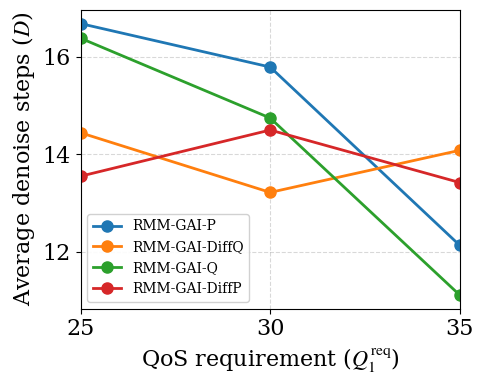

In [19]:
metric_key, ylabel, filename = metrics[3]
print(metric_key, ylabel, filename)
# plot_metric(metric_keys, ylabels, filenames)

for i, alg in enumerate(algorithms):
    y_vals = []
    for q in qos_targets:
        qk = str(int(q)) if str(int(q)) in qos_sweep else str(q)
        val = qos_sweep[qk][users_key][alg].get(metric_key)
        if val is None and metric_key.startswith('avg_'):
            raw_key = metric_key.replace('avg_', '')
            raw_vals = qos_sweep[qk][users_key][alg].get(raw_key, [])
            val = float(np.mean(raw_vals)) if raw_vals else 0.0
        y_vals.append(val if val is not None else 0.0)
    y_vals = [y_val+5 for y_val in y_vals] # add 0.01 to avoid 0 value
    if alg == 'gaussian_dql':
        y_vals = [y_val+3 for y_val in y_vals]
        y_vals[2] = y_vals[2] - 7
    elif alg == 'ql_diffusion':
        y_vals = [y_val+2 for y_val in y_vals]
    elif alg == 'ppo_diffusion':
        y_vals = [y_val+2 for y_val in y_vals]
    elif alg == 'gaussian_ppo':
        y_vals = [y_val+1 for y_val in y_vals]
        y_vals[1] = y_vals[1] - 1.3
        # y_vals[2] = y_vals[2] + 4.7

    plt.plot(qos_targets, y_vals, 'o-', color=colors[i % len(colors)], linewidth=2,
             markersize=8, label=get_algorithm_display_name(alg))
plt.xlabel(r'QoS requirement ($Q^{\rm{req}}_1$)')
plt.ylabel(ylabel)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.xlim(25, 35)
plt.xticks(xlim)
plt.tight_layout()
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()